In [ ]:
# Import python libraries needed

import numpy as np                  # for general math and array computations
import matplotlib.pyplot as plt     # for plotting


In [ ]:
# These functions define the "true" distribution of points
#   a given point has 
#       - probability p of being uniformly on the circle of radius 0.5 centered at (1,1)
#       - probability of 1-p of being uniformly within the square with corners (0,0) and (-1,-1)

# To randomly generate 100 points, call generate_points(100)

def pt_on_sphere():
    theta = np.random.uniform(0,2*np.pi)
    return [0.5*np.sin(theta)+1.0,0.5*np.cos(theta)+1.0]

def pt_in_square():
    x = np.random.uniform(0,1) - 1.0
    y = np.random.uniform(0,1) - 1.0
    return [x,y]

def generate_points(numpts):
    p = 0.2 #probability of point being on the circle (vs square)
    componenet = np.random.choice([0, 1], numpts, p=[1-p, p])
    pts = [pt_in_square() if comp == 0 else pt_on_sphere() for comp in componenet]
    return np.array(pts)

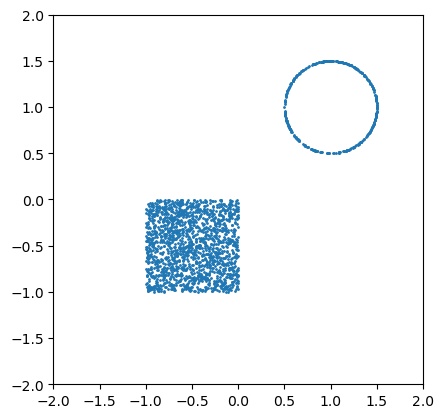

In [ ]:
# Plot 2000 random points to visualize the distribution

pts = generate_points(2000)

fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(pts[:, 0], pts[:, 1], s=1)
ax.set_ylim([-2, 2])
ax.set_xlim([-2, 2])
ax.set_aspect('equal')
plt.show()


In [86]:
# Define the diffusion process
T = 500
betas = np.linspace(1e-4, 0.01, T)
alphas = 1 - betas
alphabar = np.cumprod(alphas)

def forward_process_points(numpts, t):
    pts = generate_points(numpts)
    gaussians = np.random.normal(0,1,(numpts,2))
    new_pts = np.array([[np.sqrt(alphabar[t])*pt[0]+np.sqrt(1-alphabar[t])*gaussians[i,0],np.sqrt(alphabar[t])*pt[1]+np.sqrt(1-alphabar[t])*gaussians[i,1]] for i, pt in enumerate(pts)])
    return new_pts

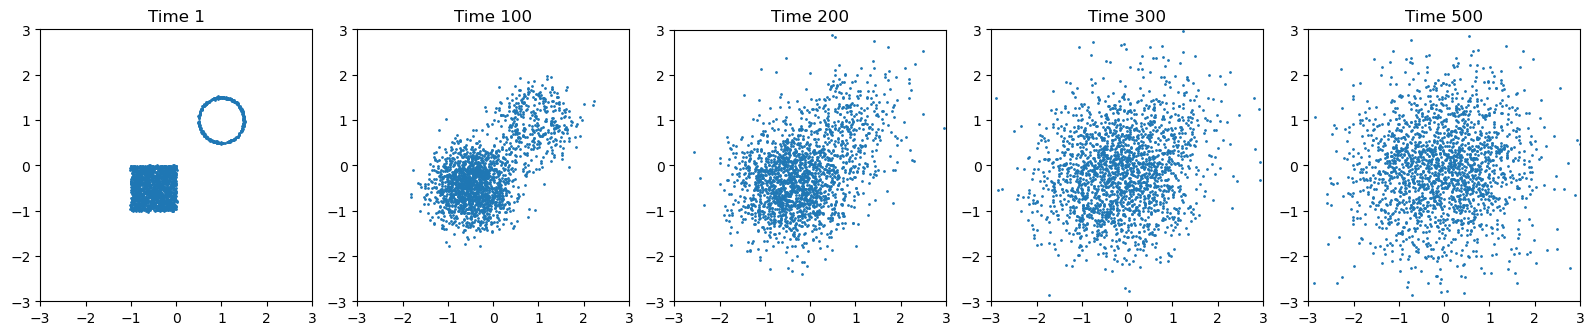

In [89]:
# Plot points at various times through the forward process

times = [0,99,199,299,499]


fig, axes = plt.subplots(1, len(times), figsize=(16, 4))

for i, ax in enumerate(axes):
    pts = forward_process_points(2000,times[i])
    ax.scatter(pts[:, 0], pts[:, 1], s=1)
    ax.set_ylim([-3, 3])
    ax.set_xlim([-3, 3])
    ax.set_aspect('equal')
    ax.set_title(f"Time {times[i]+1}")

plt.tight_layout()
plt.show()
